# Mismatch Adjoint with averaging
## Problem

We want to solve

$$\min\limits_{X\in\mathbb{R}^{n}} \frac{1}{2}\|Ax-b\|^2 + \iota_{\mathcal{C}}(x)$$

where $A\in\mathbb{R}^{m\times n}$ and

$$\mathcal{C} = \{x:\|x\|_1\leq \rho\}$$

The gradient of the objective function is given by

$$\nabla f(x) = A^*(Ax-b)$$

which we will compute instead as

$$\widehat{\nabla f}(x) = K(Ax-b)$$

with a matrix $K$.

In [1]:
import sys
import os

# Get the current working directory
current_dir = os.getcwd()

# Add the parent directory to the system path
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

# Now you can import from frank_wolfe
from frank_wolfe import *
from frank_wolfe.core.utils import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
class MismatchObjective(ObjectiveFunction):
    def __init__(self, A_operator, A_adjoint, K_operator, b):
        self.A_operator = A_operator
        self.A_adjoint = A_adjoint
        self.K_operator = K_operator
        self.b = b
    
    def evaluate(self, X):
        return 0.5 * (np.linalg.norm(self.A_operator(X) - self.b) ** 2)
    
    def mismatch_gradient(self, X):
        return self.K_operator(self.A_operator(X) - self.b)
    
    def true_gradient(self, X):
        return self.A_adjoint(self.A_operator(X) - self.b)

In [3]:
n = int(1e2)
m = int(1e1)
A = np.random.rand(m, n)
At = A.T
noise = 0.25*(2 * np.random.rand(n,m) - 1)
K = At + noise
X_ground_truth = np.random.rand(n)
X_small = X_ground_truth < 0.8
X_ground_truth[X_small] = 0
b = A @ X_ground_truth
X0 = np.random.rand(n)
X0 = X0 / (1.5 * np.linalg.norm(X0, ord=1))

In [4]:
# Create the LMO function
radius = 1 * np.linalg.norm(X_ground_truth, ord=1)
constraint_set = 'l1_ball'
lmo_fn = create_lmo(radius, constraint_set)

def A_operator(X):
    return A @ X

def A_adjoint(X):
    return A.T @ X

def K_operator(X):
    return K @ X

# Initialize the objective
objective_fn = MismatchObjective(A_operator, A_adjoint, K_operator, b)

# Create an instance of the FrankWolfe class
Mismatch = MismatchFrankWolfe(objective_fn, lmo_fn)

n_steps = int(1e5)

In [5]:
# Run the algorithm with averaging and mismatch
Mismatch.run(X0, n_steps=n_steps, mismatch=True, averaging=True)
mma_func_vals = Mismatch.func_vals
mma_gaps = Mismatch.gaps

(Mismatch Frank-Wolfe with Averaging) Progress: 100%|██████████| 100000/100000 [00:02<00:00, 46052.73it/s]


In [6]:
# Run the algorithm without averaging but with mismatch
Mismatch.run(X0, n_steps=n_steps, mismatch=True, averaging=False)
mm_func_vals = Mismatch.func_vals
mm_gaps = Mismatch.gaps

(Mismatch Frank-Wolfe) Progress: 100%|██████████| 100000/100000 [00:02<00:00, 49028.24it/s]


In [7]:
# Run the algorithm with averaging but without mismatch
Mismatch.run(X0, n_steps=n_steps, mismatch=False, averaging=True)
va_func_vals = Mismatch.func_vals
va_gaps = Mismatch.gaps

(Frank-Wolfe with Averaging) Progress: 100%|██████████| 100000/100000 [00:02<00:00, 49887.36it/s]


In [8]:
# Run the algorithm without averaging or mismatch
Mismatch.run(X0, n_steps=n_steps, mismatch=False, averaging=False)
v_func_vals = Mismatch.func_vals
v_gaps = Mismatch.gaps

(Frank-Wolfe) Progress: 100%|██████████| 100000/100000 [00:01<00:00, 50879.33it/s]


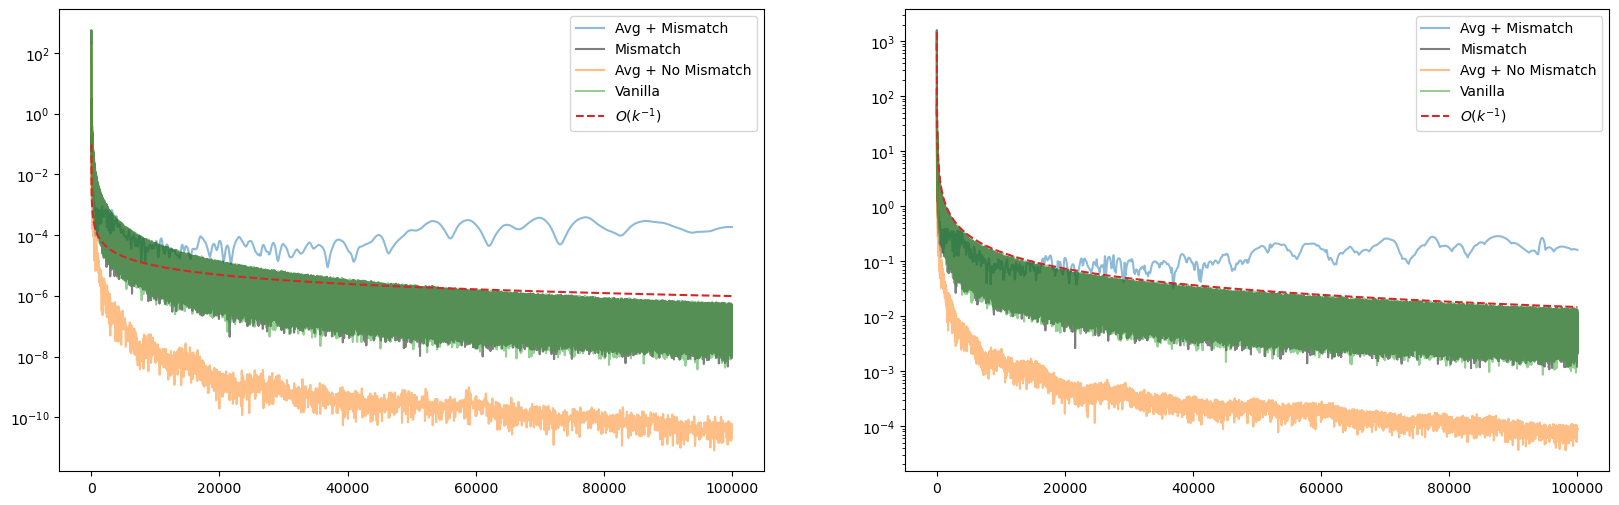

In [9]:
n_steps = len(v_gaps)
fig, axs = plt.subplots(1, 2, figsize=(20, 6))
axs[0].semilogy(mma_func_vals, label='Avg + Mismatch', alpha=0.5)
axs[0].semilogy(mm_func_vals, label='Mismatch', alpha=0.5, color='black')
axs[0].semilogy(va_func_vals, label='Avg + No Mismatch', alpha=0.5)
axs[0].semilogy(v_func_vals, label='Vanilla', alpha=0.5)
axs[0].semilogy(range(0, n_steps), (n_steps + 1) * (1.1 * v_func_vals[n_steps//2]) / (np.array(range(1, n_steps + 1))), '--', label=r'$O\left(k^{-1}\right)$')
axs[0].legend()
axs[1].semilogy(mma_gaps, label='Avg + Mismatch', alpha=0.5)
axs[1].semilogy(mm_gaps, label='Mismatch', alpha=0.5, color='black')
axs[1].semilogy(va_gaps, label='Avg + No Mismatch', alpha=0.5)
axs[1].semilogy(v_gaps, label='Vanilla', alpha=0.5)
axs[1].semilogy(range(0, n_steps), (n_steps + 1) * (1.1 * v_gaps[n_steps//2]) / (np.array(range(1, n_steps + 1))), '--', label=r'$O\left(k^{-1}\right)$')
axs[1].legend()

(Frank-Wolfe) Progress: 100%|██████████| 100000/100000 [00:01<00:00, 53587.17it/s]


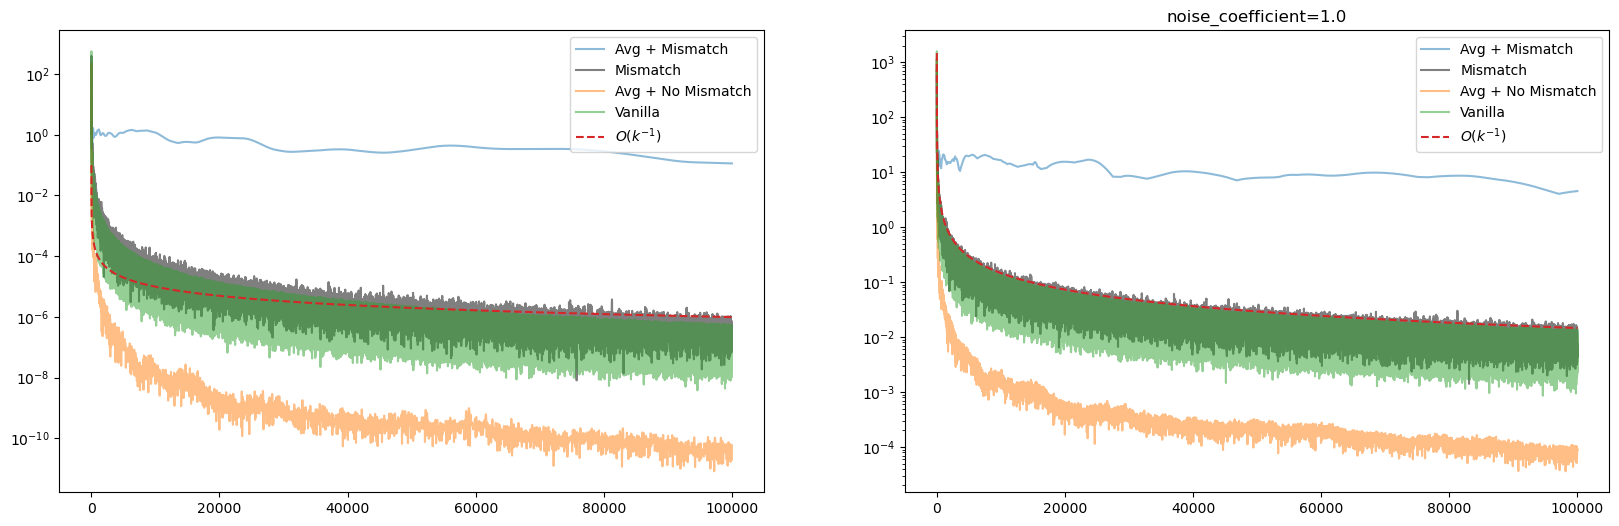

(Frank-Wolfe) Progress: 100%|██████████| 100000/100000 [00:01<00:00, 53486.58it/s]


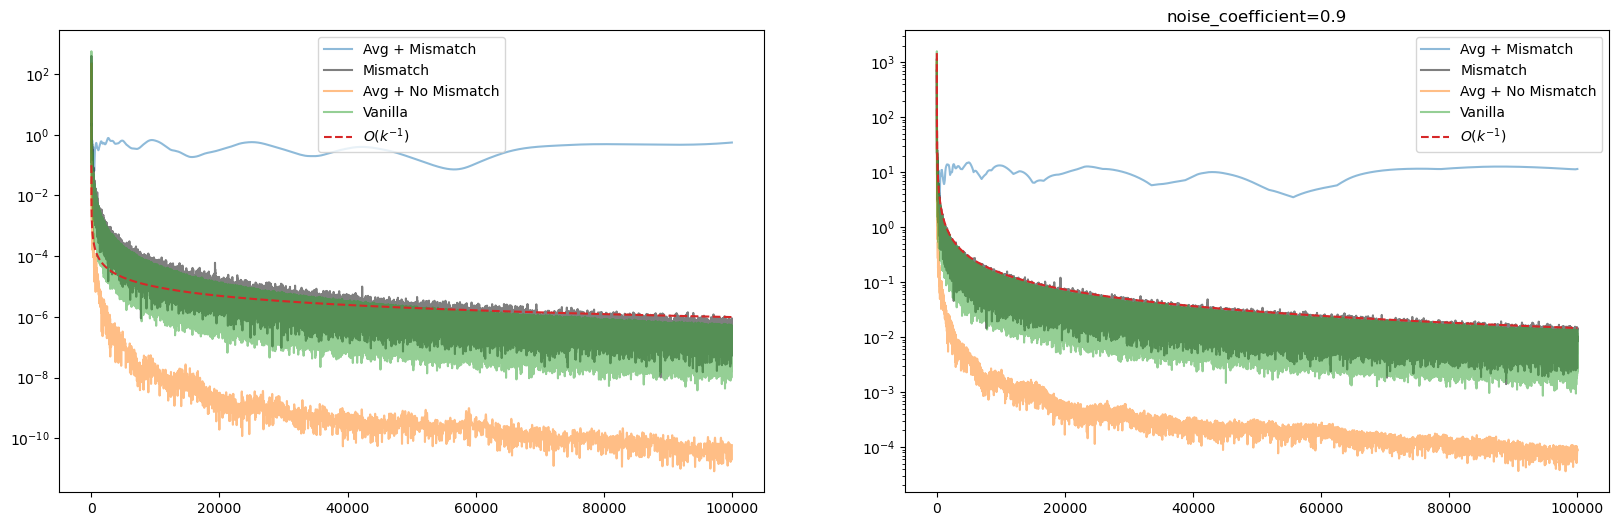

(Frank-Wolfe) Progress: 100%|██████████| 100000/100000 [00:01<00:00, 54999.54it/s]


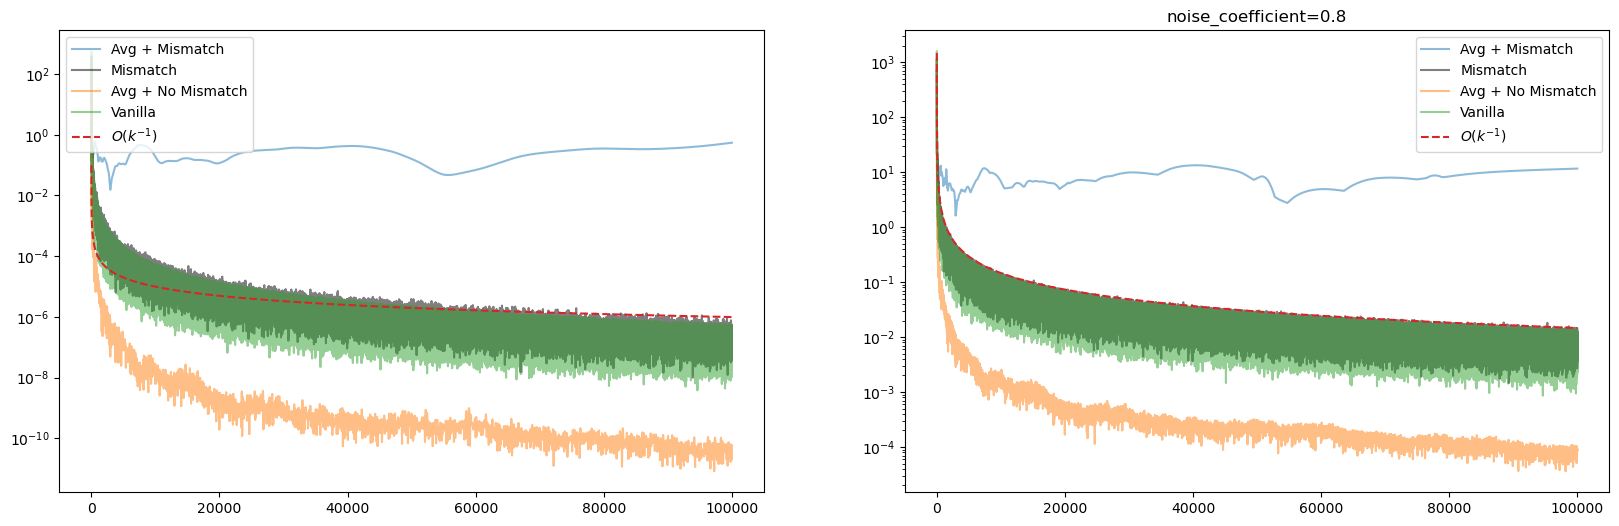

(Frank-Wolfe) Progress: 100%|██████████| 100000/100000 [00:02<00:00, 49772.89it/s]


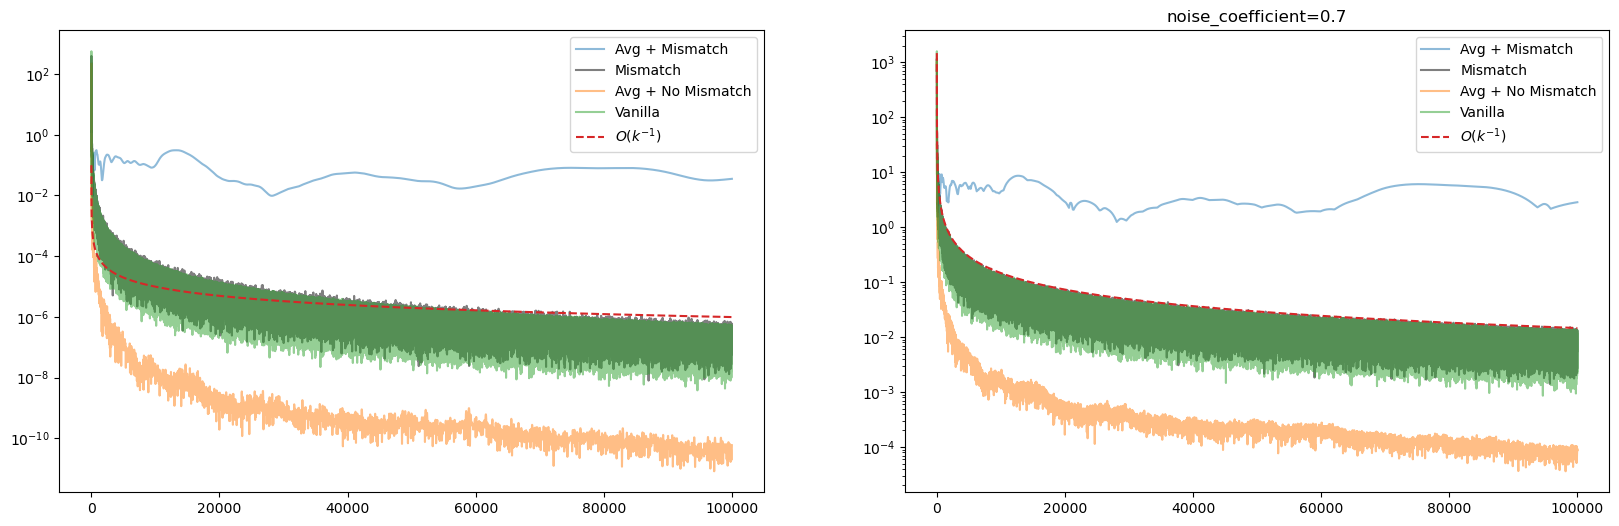

(Frank-Wolfe) Progress: 100%|██████████| 100000/100000 [00:01<00:00, 54679.71it/s]


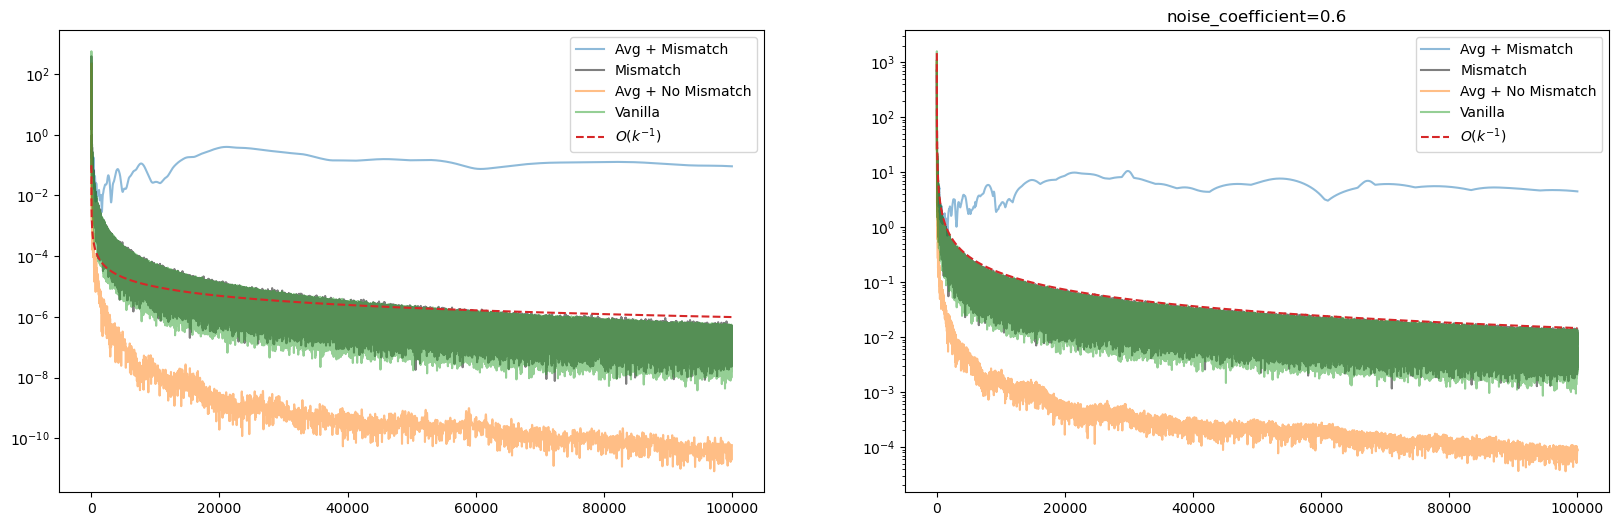

(Frank-Wolfe) Progress: 100%|██████████| 100000/100000 [00:01<00:00, 53801.30it/s]


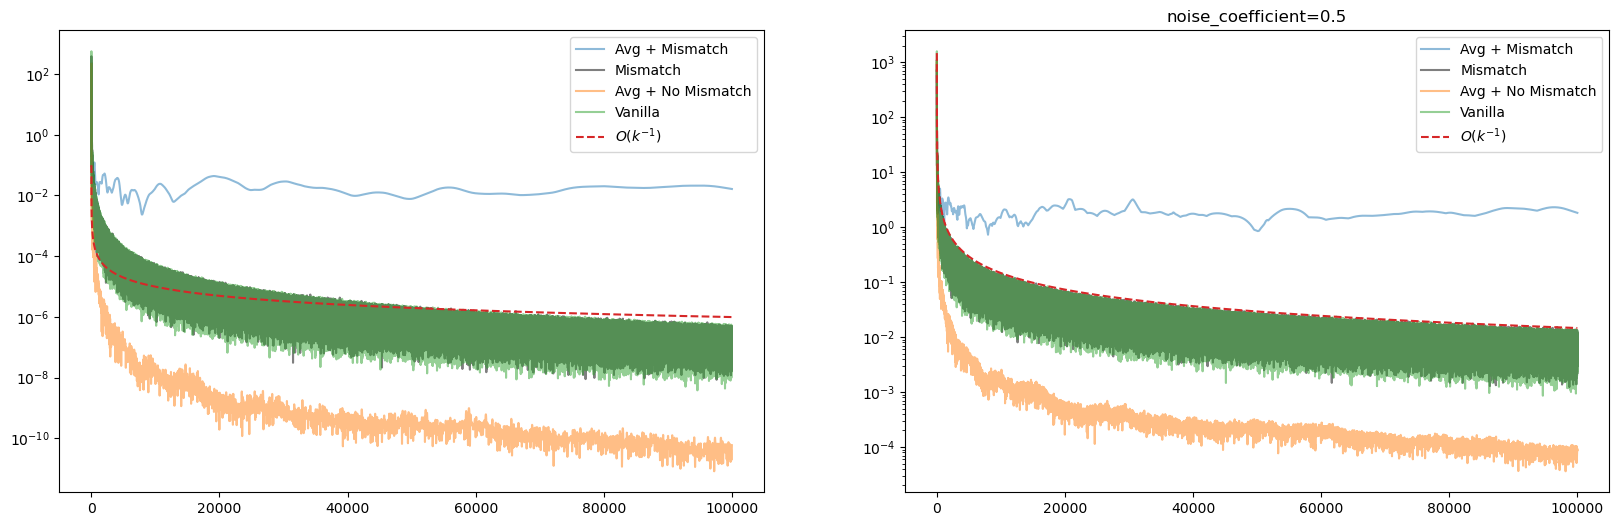

(Frank-Wolfe) Progress: 100%|██████████| 100000/100000 [00:01<00:00, 54024.30it/s]


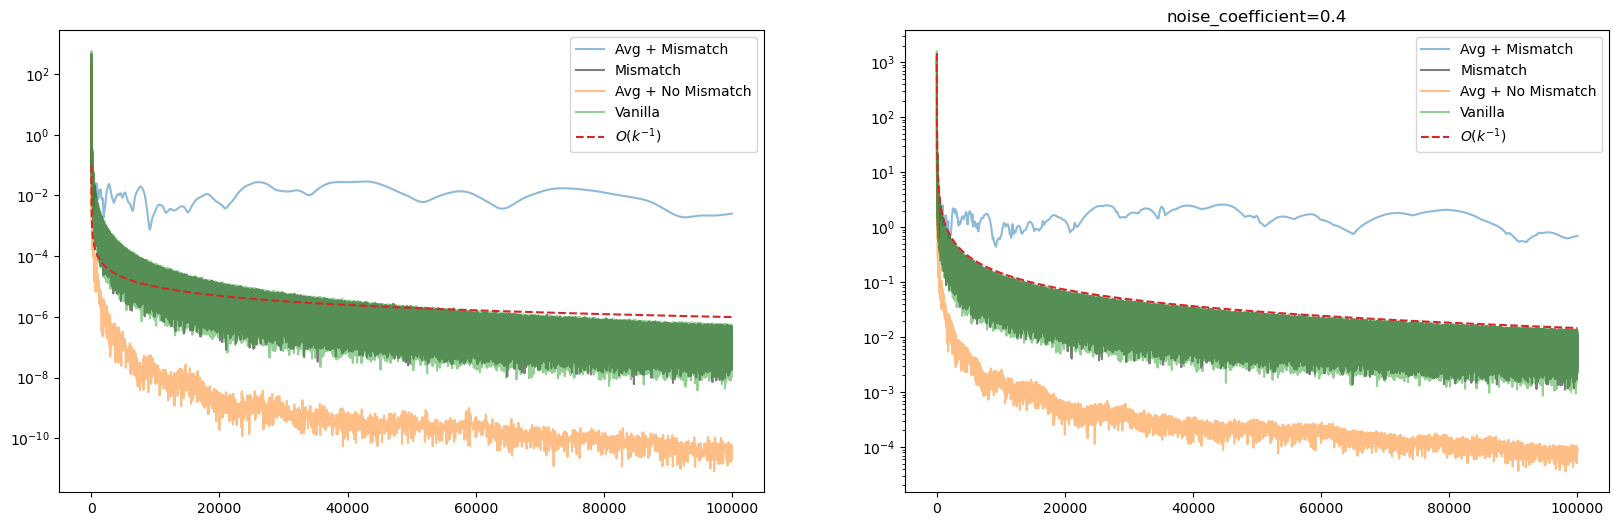

(Frank-Wolfe) Progress: 100%|██████████| 100000/100000 [00:02<00:00, 49260.55it/s]


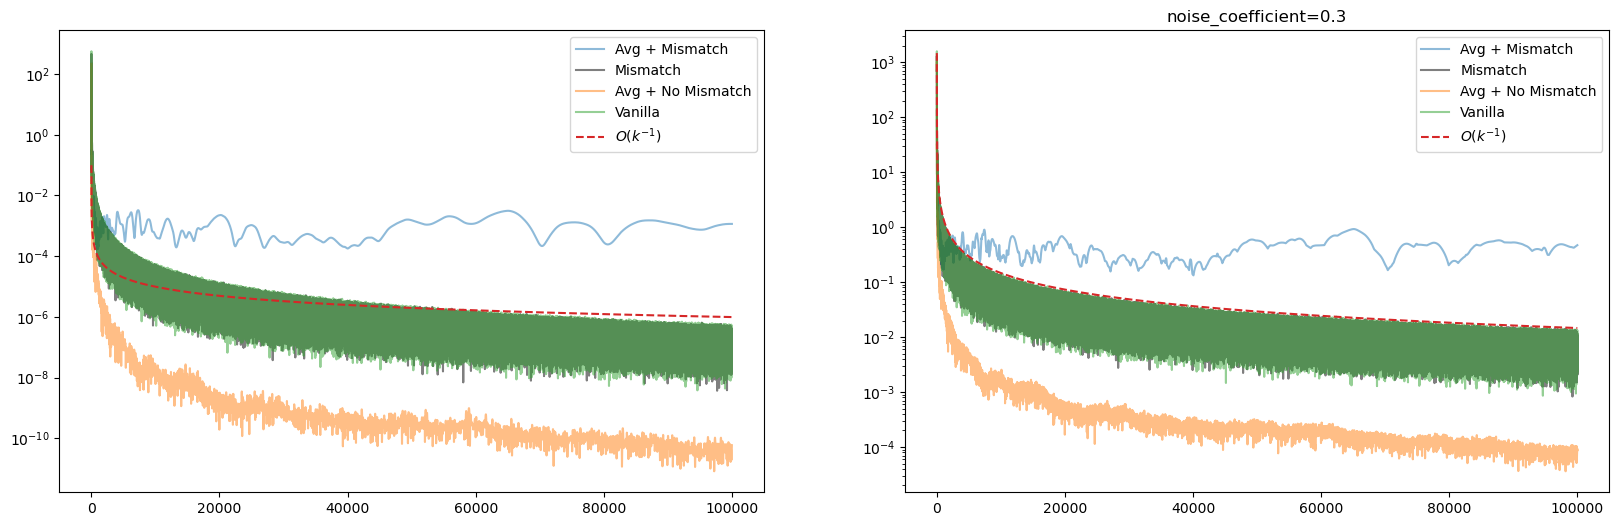

(Frank-Wolfe) Progress: 100%|██████████| 100000/100000 [00:01<00:00, 55302.57it/s]


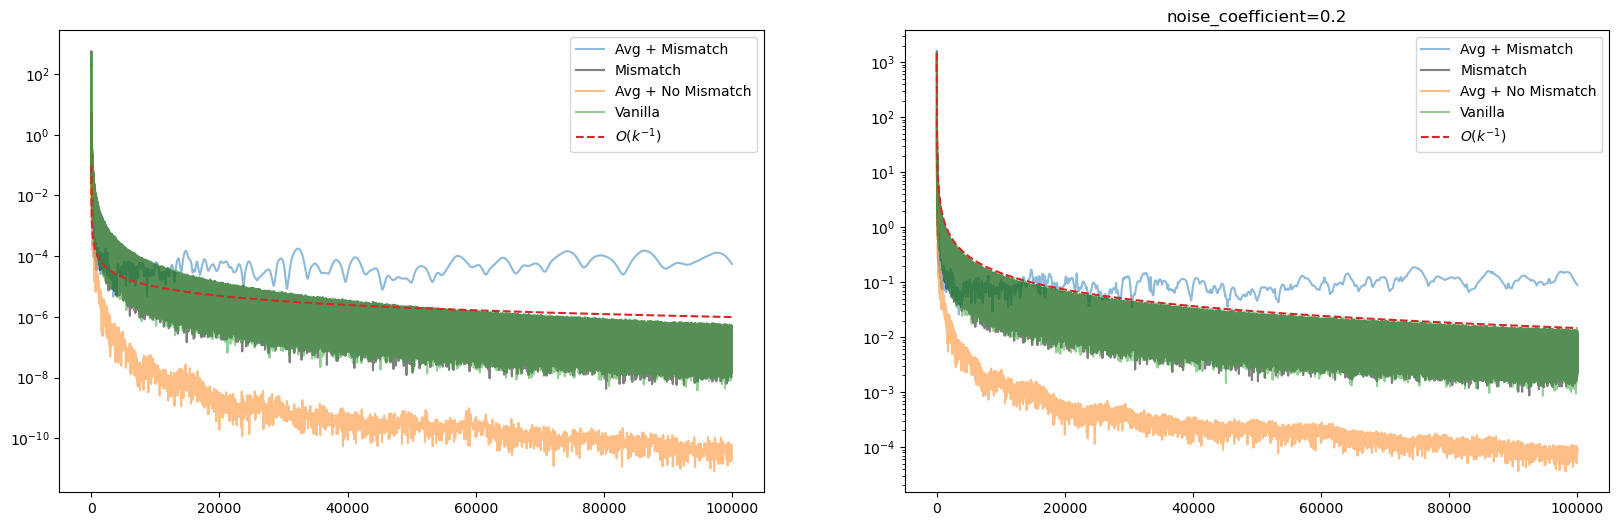

(Mismatch Frank-Wolfe) Progress:  67%|██████▋   | 66971/100000 [00:01<00:00, 47496.72it/s]


KeyboardInterrupt: 

In [10]:
noise_coefficients = [1.0, .9, .8, .7, .6, .5, .4, .3, .2, .1]
base_noise = (2 * np.random.rand(n,m) - 1)
for noise_coefficient in noise_coefficients:
    noise = noise_coefficient * base_noise
    K = At + noise

    # Create the LMO function
    radius = 1 * np.linalg.norm(X_ground_truth, ord=1)
    constraint_set = 'l1_ball'
    lmo_fn = create_lmo(radius, constraint_set)

    def A_operator(X):
        return A @ X

    def A_adjoint(X):
        return A.T @ X

    def K_operator(X):
        return K @ X

    # Initialize the objective
    objective_fn = MismatchObjective(A_operator, A_adjoint, K_operator, b)

    # Create an instance of the FrankWolfe class
    Mismatch = MismatchFrankWolfe(objective_fn, lmo_fn)

    n_steps = int(1e5)

    # Run the algorithm with averaging and mismatch
    Mismatch.run(X0, n_steps=n_steps, mismatch=True, averaging=True)
    mma_func_vals = Mismatch.func_vals
    mma_gaps = Mismatch.gaps

    # Run the algorithm without averaging but with mismatch
    Mismatch.run(X0, n_steps=n_steps, mismatch=True, averaging=False)
    mm_func_vals = Mismatch.func_vals
    mm_gaps = Mismatch.gaps

    # Run the algorithm with averaging but without mismatch
    Mismatch.run(X0, n_steps=n_steps, mismatch=False, averaging=True)
    va_func_vals = Mismatch.func_vals
    va_gaps = Mismatch.gaps

    # Run the algorithm without averaging or mismatch
    Mismatch.run(X0, n_steps=n_steps, mismatch=False, averaging=False)
    v_func_vals = Mismatch.func_vals
    v_gaps = Mismatch.gaps

    fig, axs = plt.subplots(1, 2, figsize=(20, 6))
    axs[0].semilogy(mma_func_vals, label='Avg + Mismatch', alpha=0.5)
    axs[0].semilogy(mm_func_vals, label='Mismatch', alpha=0.5, color='black')
    axs[0].semilogy(va_func_vals, label='Avg + No Mismatch', alpha=0.5)
    axs[0].semilogy(v_func_vals, label='Vanilla', alpha=0.5)
    axs[0].semilogy(range(0, n_steps), (n_steps + 1) * (1.1 * v_func_vals[n_steps//2]) / (np.array(range(1, n_steps + 1))), '--', label=r'$O\left(k^{-1}\right)$')
    axs[0].legend()
    axs[1].semilogy(mma_gaps, label='Avg + Mismatch', alpha=0.5)
    axs[1].semilogy(mm_gaps, label='Mismatch', alpha=0.5, color='black')
    axs[1].semilogy(va_gaps, label='Avg + No Mismatch', alpha=0.5)
    axs[1].semilogy(v_gaps, label='Vanilla', alpha=0.5)
    axs[1].semilogy(range(0, n_steps), (n_steps + 1) * (1.1 * v_gaps[n_steps//2]) / (np.array(range(1, n_steps + 1))), '--', label=r'$O\left(k^{-1}\right)$')
    axs[1].legend()
    plt.title(f'{noise_coefficient=}')
    plt.show()